# Kronos baseline — the forecaster on its own

Before the triage agent, the critic, or the memory loop: **how good is the raw
Kronos-small forecast** on this task (next-day close-to-close, 40 US large-caps,
graded on the `asof` bar)?

### Contamination check

Kronos-small's pretraining data ends **~June 2024** (Shi et al., *Kronos: A
Foundation Model for the Language of Financial Markets*, arXiv:2508.02739 — test
period starts July 2024). The replay window is **2025-05-01 → 2025-08-01**, about
**11 months out of sample**. Kronos has never seen these price paths; the
forecasts are genuine predictions, not lookups.


In [1]:
import os
if "src" not in os.listdir("."):        # so `import src` works from notebooks/
    os.chdir("..")

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import baseline
j = baseline._frame()
rep = baseline.report()
print(rep["window"], "|", rep["forecast_days"], "forecast-days,",
      rep["sessions"], "sessions,", rep["tickers"], "tickers")

['2025-05-01', '2025-08-01'] | 2560 forecast-days, 64 sessions, 40 tickers


## 1 · Calibration (PIT)

If the forecast distribution were calibrated, the actual close's quantile
position (`actual_quantile`) would be **uniform on [0, 1]**. Excess mass in the
end bins = the intervals are too tight (overconfident).

In [3]:
cal = baseline.calibration(j); cal

{'n': 2560,
 'pit_mean': 0.499,
 'pit_std': 0.323,
 'ks_vs_uniform': 0.079,
 'pit_deciles': [0.142,
  0.088,
  0.103,
  0.083,
  0.097,
  0.079,
  0.081,
  0.088,
  0.092,
  0.147],
 'frac_in_05_95': 0.777,
 'frac_in_25_75': 0.41}

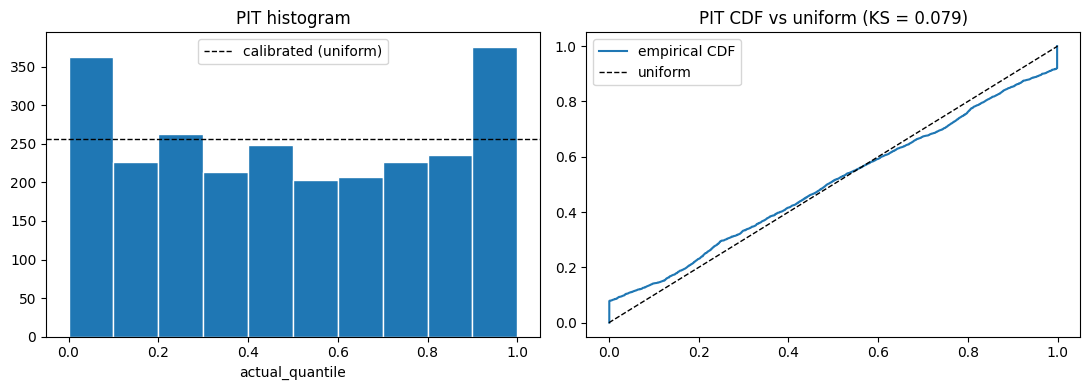

In [4]:
q = j["actual_quantile"].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(q, bins=np.linspace(0,1,11), edgecolor="white")
ax[0].axhline(len(q)/10, ls="--", c="k", lw=1, label="calibrated (uniform)")
ax[0].set_title("PIT histogram"); ax[0].set_xlabel("actual_quantile"); ax[0].legend()
xs = np.sort(q)
ax[1].plot(xs, np.arange(1,len(xs)+1)/len(xs), label="empirical CDF")
ax[1].plot([0,1],[0,1], ls="--", c="k", lw=1, label="uniform")
ax[1].set_title(f"PIT CDF vs uniform (KS = {cal['ks_vs_uniform']})"); ax[1].legend()
plt.tight_layout(); plt.show()

In [5]:
print(f"90% envelope (q05-q95) covers: {cal['frac_in_05_95']:.0%}   (target 90%)")
print(f"50% band     (q25-q75) covers: {cal['frac_in_25_75']:.0%}   (target 50%)")
print("=> the distribution is OVERCONFIDENT — real moves land in the tails "
      "more often than the model implies.")

90% envelope (q05-q95) covers: 78%   (target 90%)
50% band     (q25-q75) covers: 41%   (target 50%)
=> the distribution is OVERCONFIDENT — real moves land in the tails more often than the model implies.


## 2 · Direction

Does the sign of the forecast median call the sign of the actual move? Compare to
the naive 'always up' rule.

In [6]:
d = baseline.direction(j); d

{'up_base_rate': 0.546,
 'median_sign_hit': 0.495,
 'p_up_gt_half_hit': 0.495,
 'hit_vs_always_up': -0.052}

In [7]:
print(f"up base rate this window:      {d['up_base_rate']:.1%}")
print(f"median-sign hit rate:          {d['median_sign_hit']:.1%}")
print(f"vs 'always guess the majority': {d['hit_vs_always_up']:+.1%}")
print("=> no directional edge at the 1-day horizon. Expected — daily equity "
      "direction is close to unpredictable from price alone.")

up base rate this window:      54.6%
median-sign hit rate:          49.5%
vs 'always guess the majority': -5.2%
=> no directional edge at the 1-day horizon. Expected — daily equity direction is close to unpredictable from price alone.


## 3 · Bias & sharpness

In [8]:
b = baseline.bias(j); b

{'mean_signed_err': 0.00039,
 'median_signed_err': -0.00038,
 'mean_abs_err': 0.01428,
 'mean_forecast_median': 0.0015,
 'mean_actual_ret': 0.00189,
 'mean_90pct_width': 0.0437}

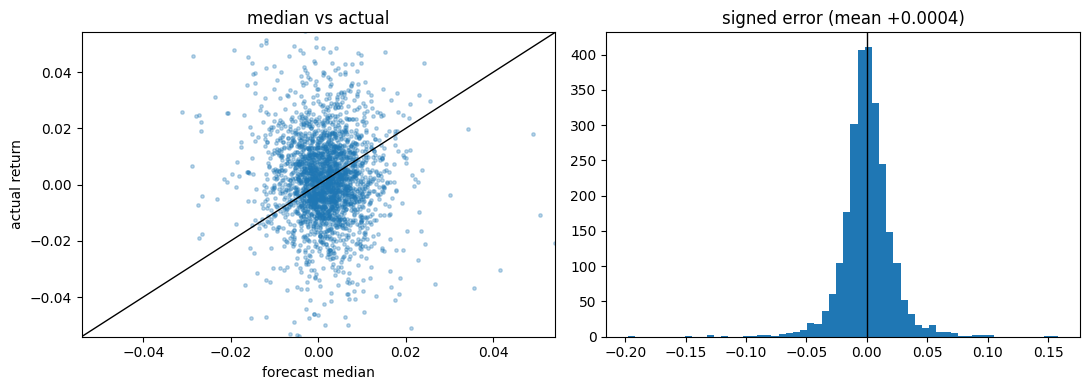

median is ~unbiased; the v1 'mild positive lean' is gone at a 120-bar lookback.


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(j["q50"], j["ret"], s=6, alpha=.3)
lim = np.percentile(np.abs(j[["q50","ret"]].values), 99)
ax[0].plot([-lim,lim],[-lim,lim], c="k", lw=1)
ax[0].set_xlim(-lim,lim); ax[0].set_ylim(-lim,lim)
ax[0].set_xlabel("forecast median"); ax[0].set_ylabel("actual return"); ax[0].set_title("median vs actual")
ax[1].hist(j["signed_err"], bins=60); ax[1].axvline(0, c="k", lw=1)
ax[1].set_title(f"signed error (mean {b['mean_signed_err']:+.4f})")
plt.tight_layout(); plt.show()
print("median is ~unbiased; the v1 'mild positive lean' is gone at a 120-bar lookback.")

## 4 · Skill — does the model know which days matter?

This is the question that decides whether triage's ranking has anything to work
with. Two candidate signals: **strength** (|median| / dispersion) and raw
**dispersion**.

In [10]:
s = baseline.skill(j); s

{'spearman_strength_vs_abs_ret': 0.036,
 'spearman_pvalue': 0.0663,
 'spearman_dispersion_vs_abs_ret': 0.247,
 'abs_ret_top_strength_decile': 0.0152,
 'abs_ret_bottom_strength_decile': 0.0115,
 'eventful_decile_ratio': 1.32}

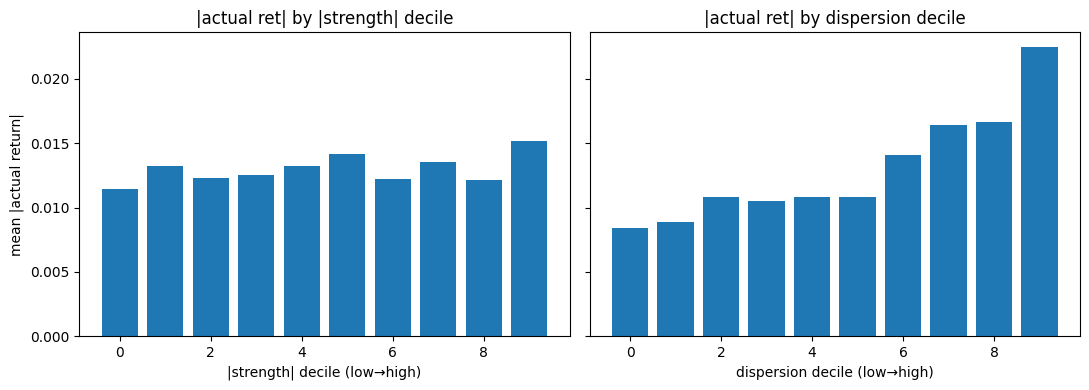

Spearman |strength| vs |ret|:  +0.036  (p=0.0663)
Spearman dispersion vs |ret|:  +0.247
=> raw strength barely orders eventful days; dispersion does better. Triage leans on strength_z (strength vs the name's own history) and the cluster read to compensate.


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, col, name in [(ax[0], "strength_abs", "|strength|"), (ax[1], "std", "dispersion")]:
    bins = pd.qcut(j[col], 10, duplicates="drop")
    m = j.groupby(bins, observed=True)["abs_ret"].mean()
    a.bar(range(len(m)), m.values); a.set_title(f"|actual ret| by {name} decile")
    a.set_xlabel(f"{name} decile (low→high)")
ax[0].set_ylabel("mean |actual return|")
plt.tight_layout(); plt.show()
print(f"Spearman |strength| vs |ret|:  {s['spearman_strength_vs_abs_ret']:+.3f}  (p={s['spearman_pvalue']})")
print(f"Spearman dispersion vs |ret|:  {s['spearman_dispersion_vs_abs_ret']:+.3f}")
print("=> raw strength barely orders eventful days; dispersion does better. "
      "Triage leans on strength_z (strength vs the name's own history) and the "
      "cluster read to compensate.")

## 5 · Over time / by name

In [12]:
baseline.by_week(j).round(3)

,n,cover_90,dir_hit,mean_signed_err
asof,,,,
2025-05-04,80,0.625,0.350,0.013
2025-05-11,200,0.860,0.510,-0.001
2025-05-18,200,0.665,0.465,0.009
2025-05-25,200,0.820,0.465,-0.008
2025-06-01,160,0.812,0.494,0.001
2025-06-08,200,0.865,0.550,0.000
2025-06-15,200,0.795,0.490,0.004
2025-06-22,160,0.781,0.494,0.000
2025-06-29,200,0.765,0.520,0.006


In [13]:
baseline.by_ticker(j).round(3).head(15)

,n,cover_90,dir_hit,mean_signed_err,mean_abs_err
ticker,,,,,
TSLA,64,0.734,0.406,-0.001,0.032
UNH,64,0.625,0.391,-0.011,0.028
AMD,64,0.750,0.453,0.009,0.025
INTC,64,0.797,0.500,-0.002,0.021
ORCL,64,0.750,0.484,0.009,0.021
NKE,64,0.641,0.406,0.005,0.021
AVGO,64,0.844,0.531,0.004,0.018
NVDA,64,0.812,0.469,0.006,0.018
LLY,64,0.781,0.656,-0.004,0.016


---
## What this means for the project

Kronos-small on this task is an **unbiased but low-skill** forecaster: it calls
direction no better than chance and its intervals are ~12 points too tight. That
is not a criticism of the loop — it is the premise. The value the desk adds is
**disciplined review and accumulating memory around a mediocre model**, not
alpha. The eval (`eval/evaluate.py`) measures the loop against that honest bar:
does triage still surface the eventful names, does the post-mortem correctly
attribute the misses, does the memory's base rate predict later outcomes.